# Parallel Iterative SLSQP — All Test Cases
Runs `iterative_parallel` on every test case generated by `generate_test_cases.ipynb`.
Results are saved under `OUTPUT_DIR` alongside the input `.npy` files.

## Imports

In [1]:
import os
import time
import glob

import numpy as np
import matplotlib.pyplot as plt

from modules.dvfopt import jacobian_det2D, iterative_parallel
from modules.dvfviz import plot_deformations, plot_grid_before_after
from modules.testcases import (
    SYNTHETIC_CASES, RANDOM_DVF_CASES, REAL_DATA_SLICES,
    make_deformation, make_random_dvf, load_slice,
)

In [2]:
INPUT_DIR = "data/test_cases"
OUTPUT_DIR = "output/test_cases/results/parallel_slsqp"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Helper

In [3]:
def run_and_show(key, deformation, msample=None, fsample=None, **kwargs):
    """Run parallel correction, save outputs, print summary, and plot."""
    save_dir = f"{OUTPUT_DIR}/{key}"

    H, W = deformation.shape[-2:]
    jac_init = jacobian_det2D(np.stack([deformation[-2, 0], deformation[-1, 0]]))
    n_neg_init = int((jac_init <= 0).sum())
    min_jdet_init = float(jac_init.min())

    print(f"\n{'='*70}")
    print(f"  {key}  |  {H}x{W}  |  neg Jdet: {n_neg_init}  |  min Jdet: {min_jdet_init:.4f}")
    print(f"{'='*70}")

    t0 = time.perf_counter()
    phi = iterative_parallel(
        deformation.copy(), save_path=save_dir, verbose=1, **kwargs
    )
    elapsed = time.perf_counter() - t0

    jac_final = jacobian_det2D(phi)
    n_neg_final = int((jac_final <= 0).sum())
    min_jdet_final = float(jac_final.min())
    l2 = float(np.sqrt(np.sum((phi - np.stack([deformation[-2, 0], deformation[-1, 0]]))**2)))

    print(f"  Time: {elapsed:.2f}s  |  neg Jdet: {n_neg_init} -> {n_neg_final}  "
          f"|  min Jdet: {min_jdet_init:.4f} -> {min_jdet_final:.4f}  |  L2: {l2:.4f}")

    plot_deformations(msample, fsample, deformation, phi, title=key)
    plot_grid_before_after(deformation, phi, title=key)
    return phi

## Case 1 — Small synthetic grids


  01a_10x10_crossing  |  10x10  |  neg Jdet: 9  |  min Jdet: -1.0246
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 9  |  min Jdet: -1.024567
[iter    1]  serial  fix (  3,  5)  neg_pixels=9
         -> neg_jdet     0  min_jdet +0.010000  L2 2.2706  win 9  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1  (serial=1, parallel=0)
  Neg-Jdet      9 ->     0
  Min Jdet  -1.024567 -> +0.010000
  L2 error         : 2.270564
  Time             : 0.17s
  Time: 0.18s  |  neg Jdet: 9 -> 0  |  min Jdet: -1.0246 -> 0.0100  |  L2: 2.2706
            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -3.9997      3.9997     -2.0200     -1.9739     -

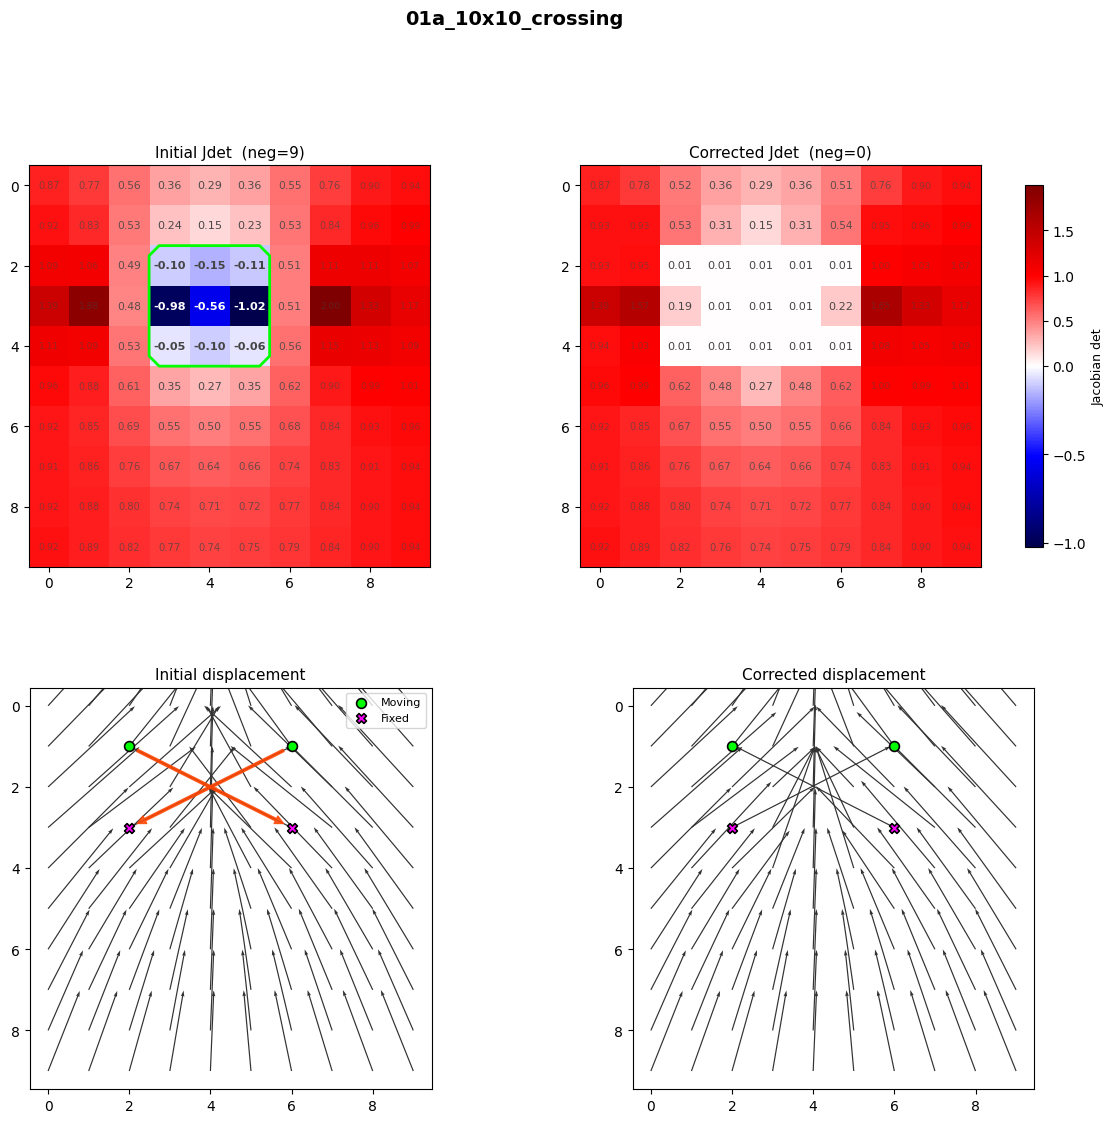

c:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\modules\dvfviz.py:734: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.92, 1])


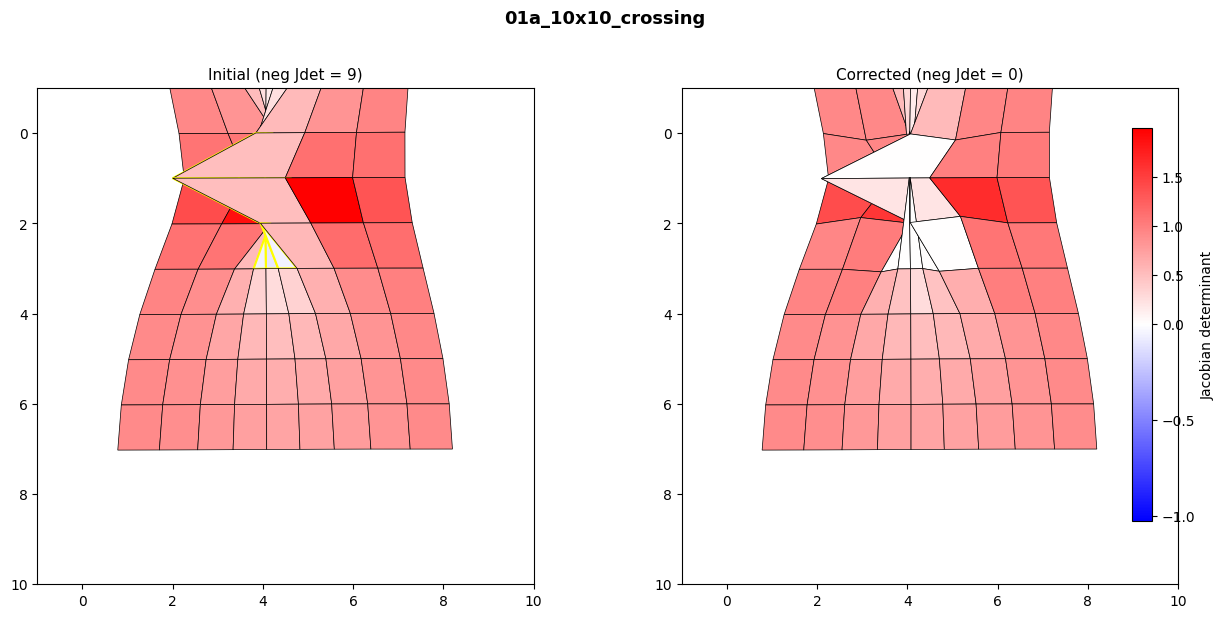


  01b_10x10_opposite  |  10x10  |  neg Jdet: 6  |  min Jdet: -1.1540
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 6  |  min Jdet: -1.154032
[iter    1]  serial  fix (  2,  1)  neg_pixels=4
         -> neg_jdet     0  min_jdet +0.010000  L2 1.4622  win 9  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1  (serial=1, parallel=0)
  Neg-Jdet      6 ->     0
  Min Jdet  -1.154032 -> +0.010000
  L2 error         : 1.462154
  Time             : 0.21s
  Time: 0.22s  |  neg Jdet: 6 -> 0  |  min Jdet: -1.1540 -> 0.0100  |  L2: 1.4622
            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -2.9998      2.9998      0.0000      0.0000     -

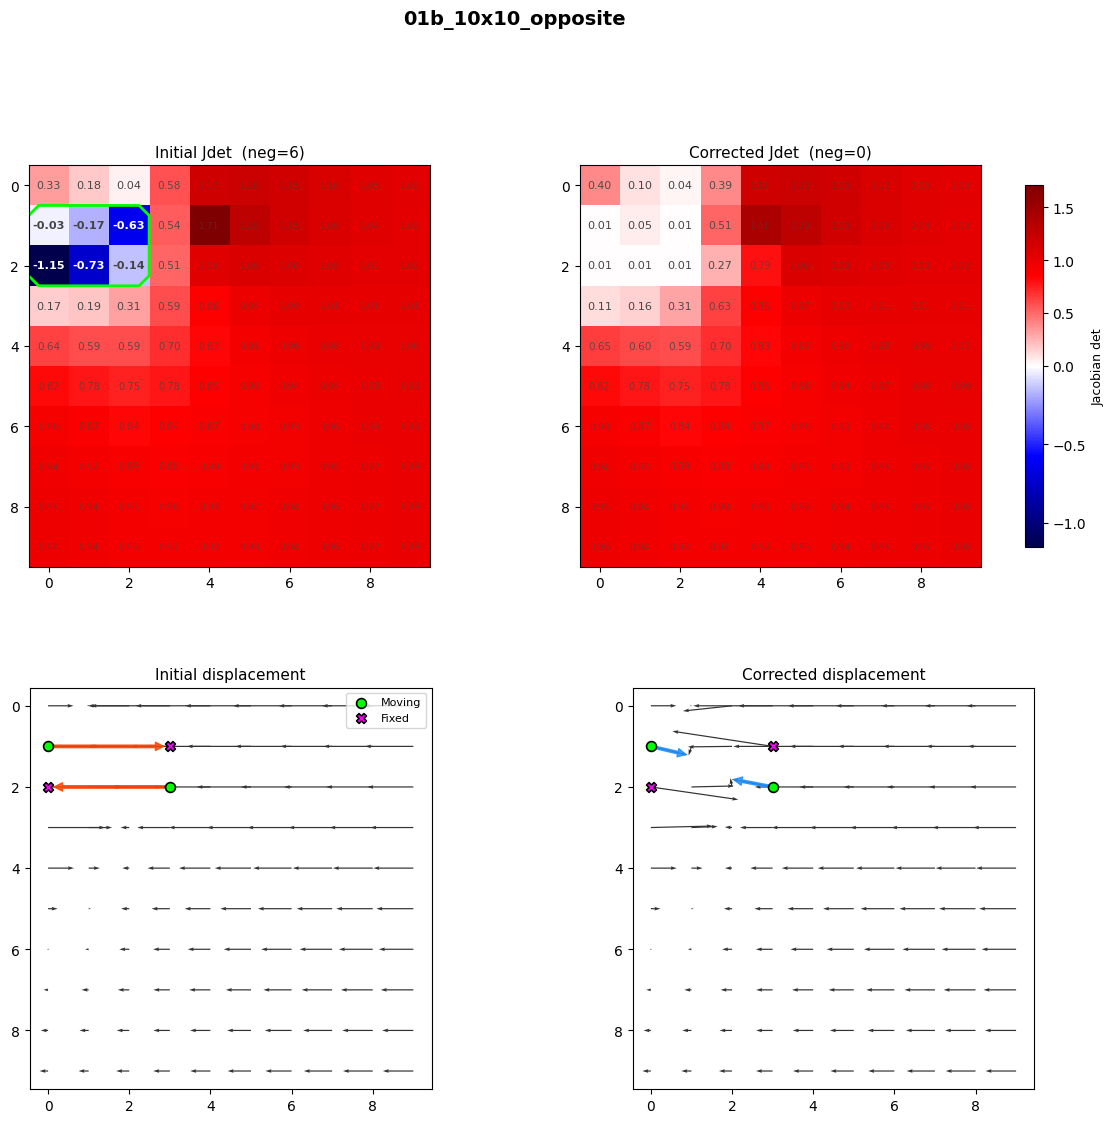

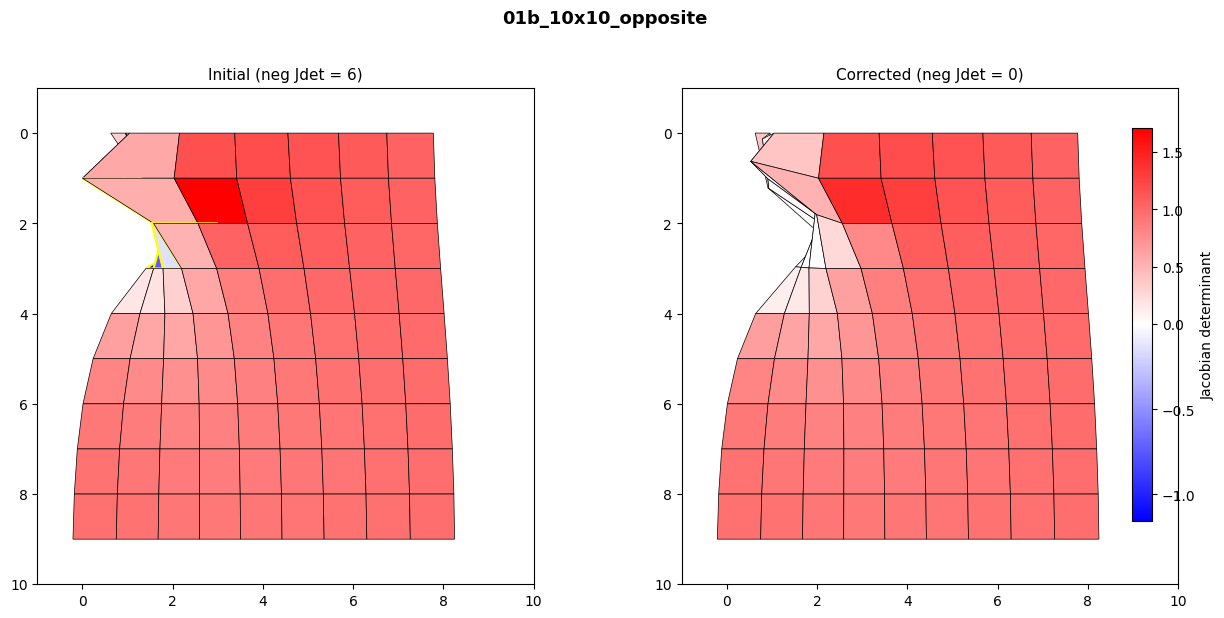


  01c_20x40_edges  |  20x40  |  neg Jdet: 29  |  min Jdet: -1.3430
[init] Grid 20x40  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 29  |  min Jdet: -1.343039
[iter    1]  parallel  batch=5  neg_pixels=26  windows=9-9
         -> neg_jdet     3  min_jdet -0.321936  L2 2.8895
[iter    2]  parallel  batch=2  neg_pixels=3  windows=11-11
         -> neg_jdet     5  min_jdet -0.279748  L2 2.8535
[iter    3]  serial  fix (  3, 32)  neg_pixels=5
         -> neg_jdet     1  min_jdet -0.141972  L2 2.9417  win 11  sub-iters 1
[iter    4]  serial  fix ( 17, 24)  neg_pixels=1
         -> neg_jdet     0  min_jdet +0.010000  L2 2.9527  win 9  sub-iters 1
[done] All Jdet > threshold after iter 4

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 20 x 40
  Iterations       : 4  (serial=2, parallel=2)
  Neg-Jdet     29 ->     0
  Min Jdet  -1.343039 -> +0.010000
  L2 error         : 2.9526

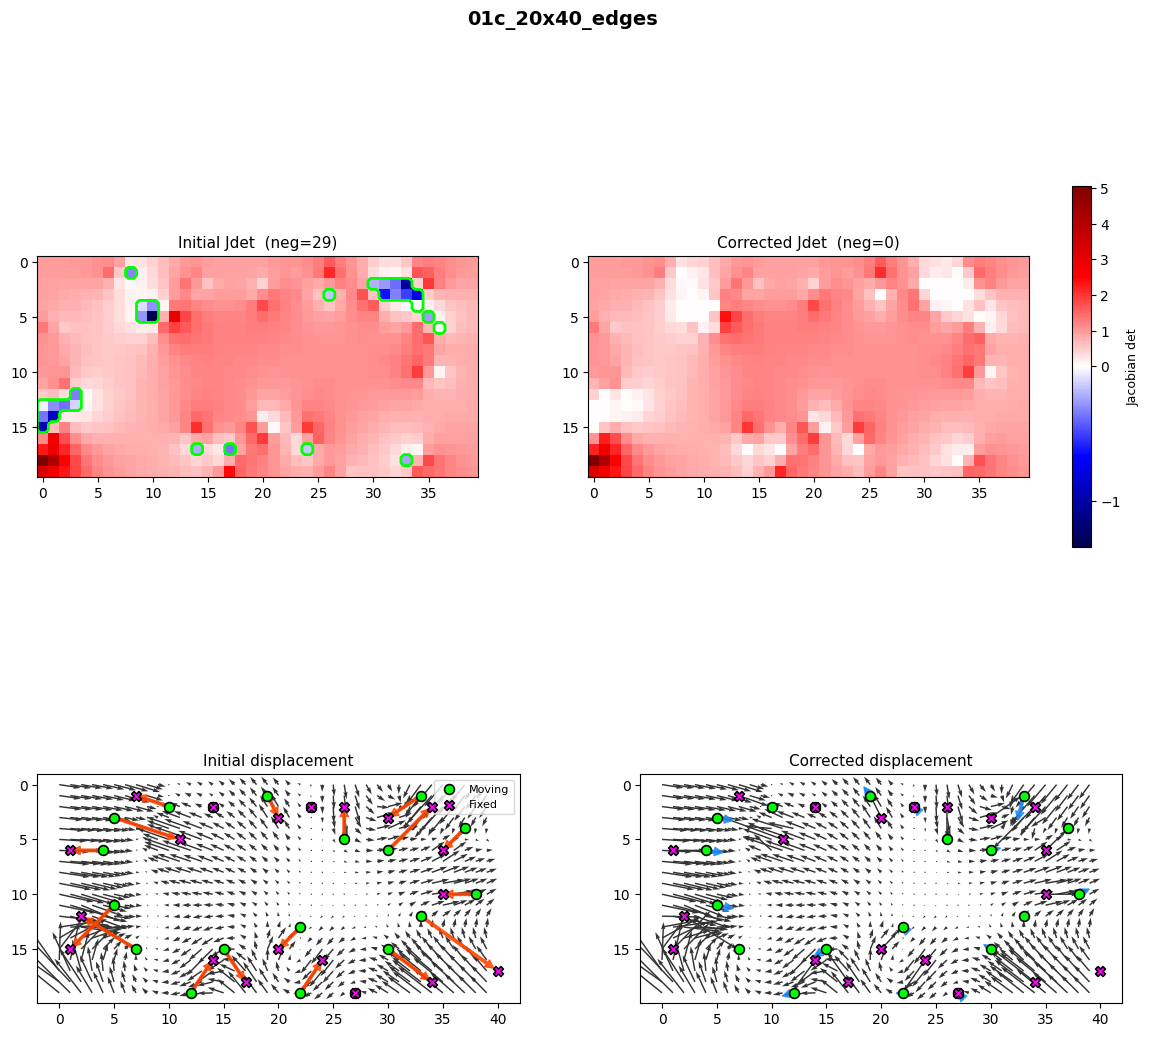

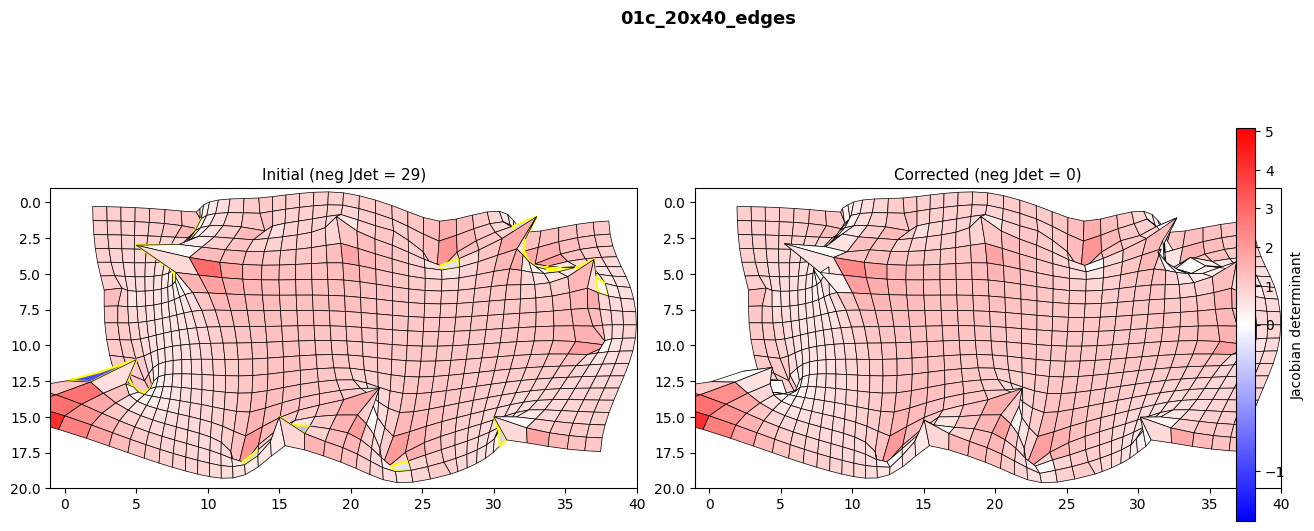


  01d_20x40_crossing  |  20x40  |  neg Jdet: 158  |  min Jdet: -3.3699
[init] Grid 20x40  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 158  |  min Jdet: -3.369923
[iter    1]  serial  fix ( 15, 11)  neg_pixels=142
         -> neg_jdet    84  min_jdet -3.309977  L2 8.9325  win 19  sub-iters 6
[iter    2]  serial  fix ( 15, 29)  neg_pixels=75
         -> neg_jdet    18  min_jdet -2.951167  L2 12.1756  win 19  sub-iters 6
[iter    3]  serial  fix ( 16, 20)  neg_pixels=16
         -> neg_jdet    22  min_jdet -2.143413  L2 15.3545  win 19  sub-iters 6
[iter    4]  parallel  batch=2  neg_pixels=22  windows=11-11
         -> neg_jdet    36  min_jdet -1.786360  L2 11.1658
[iter    5]  serial  fix ( 15, 25)  neg_pixels=32
         -> neg_jdet    18  min_jdet -2.897048  L2 12.5123  win 19  sub-iters 6
[iter    6]  serial  fix ( 15, 15)  neg_pixels=16
         -> neg_jdet    18  min_jdet -1.742034  L2 14.2984  win 19  sub-iters 6
[iter    7]  serial 

In [ ]:
for key in ["01a_10x10_crossing", "01b_10x10_opposite", "01c_20x40_edges", "01d_20x40_crossing"]:
    deformation, ms, fs = make_deformation(key)
    run_and_show(key, deformation, ms, fs)

## Case 1e–f — Random DVFs

In [ ]:
# Skipped — random DVFs take too long
# for key in ["01e_20x20_random_spirals", "01f_20x20_random_seed_42"]:
#     dvf = make_random_dvf(key)
#     run_and_show(key, dvf)

## Case 2 — Real data slices (downscaled)

In [ ]:
for key, cfg in REAL_DATA_SLICES.items():
    if cfg["scale_factor"] < 1.0:  # only downscaled for speed
        deformation, ms, fs = load_slice(cfg["slice_idx"], scale_factor=cfg["scale_factor"])
        run_and_show(key, deformation, ms, fs)

## Case 3 — Additional synthetic grids

In [ ]:
for key in ["03a_10x10_opposite", "03b_10x10_crossing", "03c_20x20_opposite", "03d_20x20_crossing"]:
    deformation, ms, fs = make_deformation(key)
    run_and_show(key, deformation, ms, fs)

### Random DVF variants

In [ ]:
# Skipped — random DVFs take too long
# for key in ["03a_10x10_random_seed_42", "03c_20x20_random_seed_42"]:
#     dvf = make_random_dvf(key)
#     run_and_show(key, dvf)

## Summary — collect all results

In [ ]:
result_dirs = sorted(glob.glob(f"{OUTPUT_DIR}/*/results.txt"))

print(f"{'Case':<35s}  {'Grid':>9s}  {'Time (s)':>9s}  {'L2':>10s}  {'Neg init':>8s}  {'Neg final':>9s}  {'Min Jdet':>10s}")
print("-" * 100)

for path in result_dirs:
    case_name = os.path.basename(os.path.dirname(path))
    lines = open(path).read()

    def _extract(label):
        for line in lines.splitlines():
            if label in line:
                return line.split(":")[-1].strip().split()[0]
        return "?"

    grid = _extract("resolution")
    runtime = _extract("run-time")
    l2 = _extract("Final L2")
    neg_start = _extract("Starting number of non-positive")
    neg_final = _extract("Final number of non-positive")
    min_jdet = _extract("Final Jacobian determinant minimum")

    print(f"{case_name:<35s}  {grid:>9s}  {runtime:>9s}  {l2:>10s}  {neg_start:>8s}  {neg_final:>9s}  {min_jdet:>10s}")